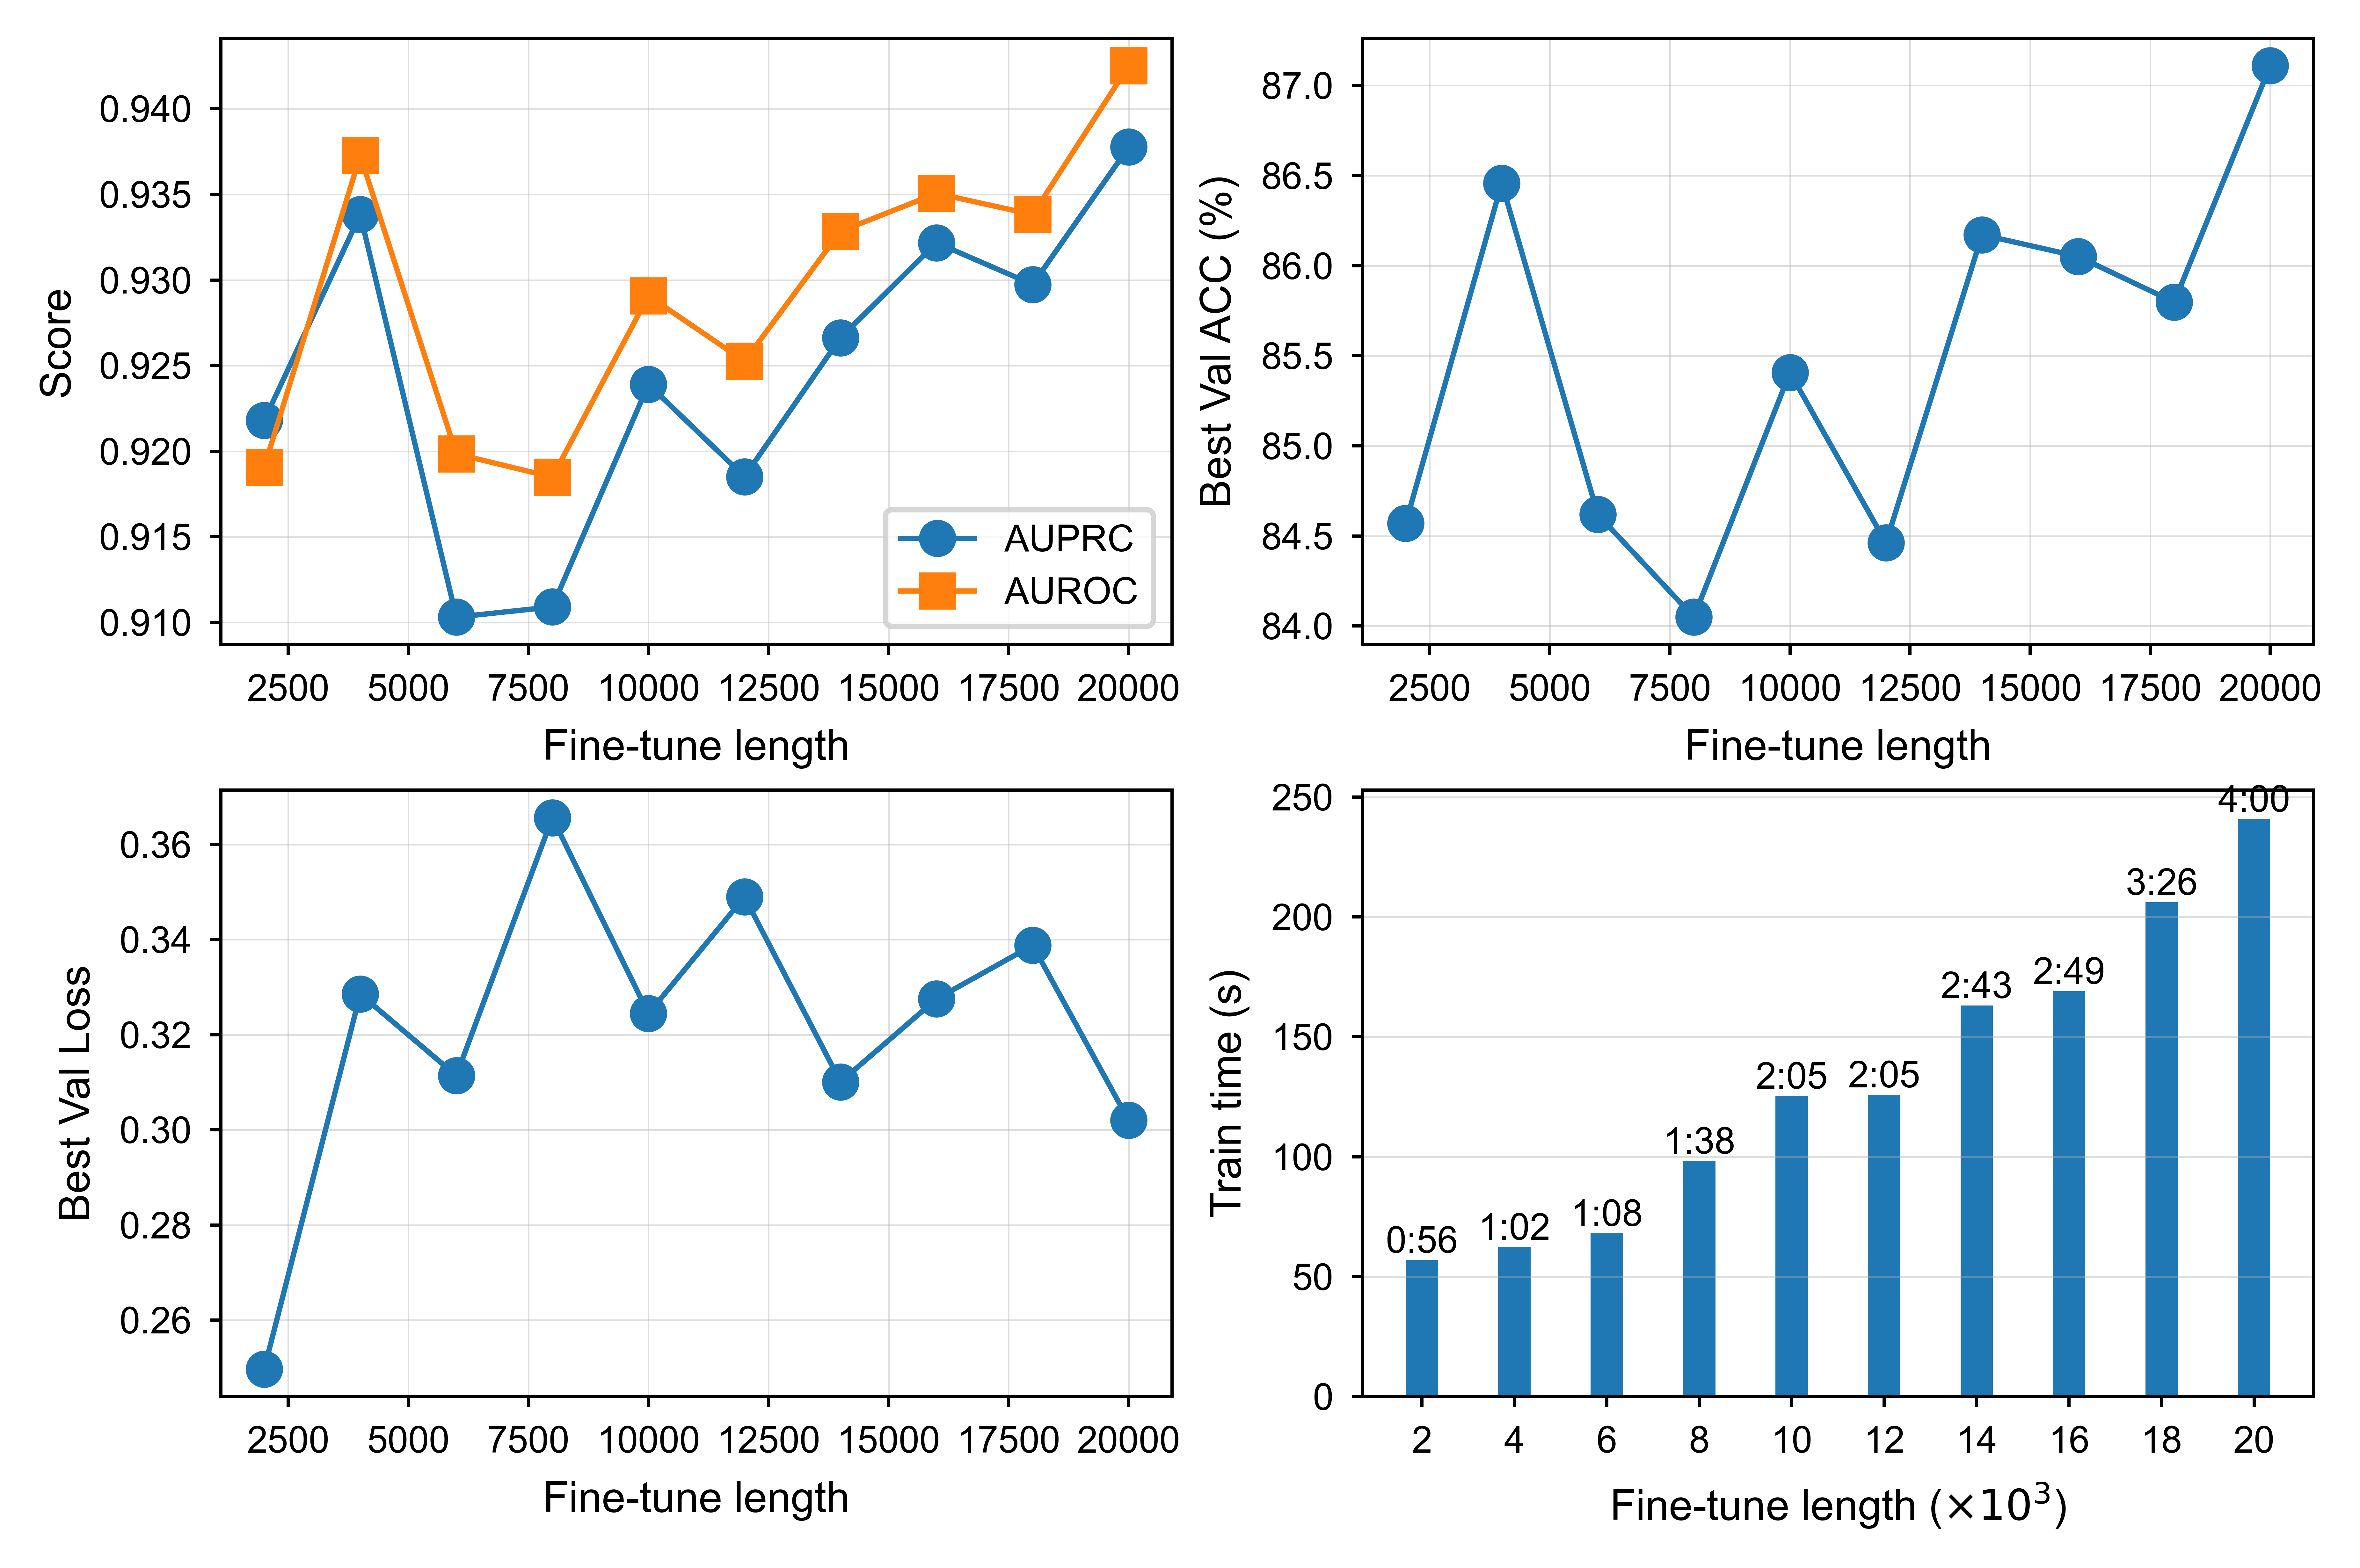

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/mnt/sunxh/sunxh/wattmamba/save_result/sample_efficiency_m5u.csv"
out_pdf  = "sample_efficiency_summary_m5u.pdf"

df = pd.read_csv(csv_path)

num_cols = [
    "length","best_epoch","best_val_loss","best_val_acc",
    "best_val_auroc","best_val_auprc","train_seconds",
    "lr","max_epochs","seed"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["length"]).sort_values("length").reset_index(drop=True)

meta = df.iloc[0]
run_tag  = str(meta.get("run_tag", ""))
modified = str(meta.get("modified", ""))
lr       = meta.get("lr", "")
max_ep   = meta.get("max_epochs", "")
seed     = meta.get("seed", "")

x = df["length"].astype(int).to_list()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.linewidth"] = 0.6

fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.0), dpi=1200)

# (1) AUPRC / AUROC
ax = axes[0, 0]
ax.plot(x, df["best_val_auprc"], marker="o", linewidth=1.0, label="AUPRC")
ax.plot(x, df["best_val_auroc"], marker="s", linewidth=1.0, label="AUROC")
ax.set_xlabel("Fine-tune length")
ax.set_ylabel("Score")
ax.legend(frameon=True, fontsize=7)
ax.grid(True, linewidth=0.3, alpha=0.4)

# (2) ACC
ax = axes[0, 1]
ax.plot(x, df["best_val_acc"], marker="o", linewidth=1.0)
ax.set_xlabel("Fine-tune length")
ax.set_ylabel("Best Val ACC (%)")
ax.grid(True, linewidth=0.3, alpha=0.4)

# (3) LOSS
ax = axes[1, 0]
ax.plot(x, df["best_val_loss"], marker="o", linewidth=1.0)
ax.set_xlabel("Fine-tune length")
ax.set_ylabel("Best Val Loss")
ax.grid(True, linewidth=0.3, alpha=0.4)

ax = axes[1, 1]
secs = df["train_seconds"].astype(float).to_list()

x_num = np.array(x, dtype=float)          # 2000, 5000, ...
x_scaled = x_num / 1e3                    # 2, 5, 8, 11, 14, 20

if len(x_scaled) >= 2:
    step = np.min(np.diff(x_scaled))
    width = step * 0.35
else:
    width = 0.6

ax.bar(x_scaled, secs, width=width)

ax.set_xlabel(r"Fine-tune length ($\times 10^3$)")
ax.set_ylabel("Train time (s)")
ax.grid(True, axis="y", linewidth=0.3, alpha=0.4)

ax.set_xticks(x_scaled)
ax.set_xticklabels([f"{v:g}" for v in x_scaled], rotation=0)

for xi, sec in zip(x_scaled, secs):
    mm = int(sec // 60)
    ss = int(sec % 60)
    ax.text(xi, sec, f"{mm}:{ss:02d}", ha="center", va="bottom", fontsize=7, rotation=0)


for ax in axes.ravel():
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.6)
    ax.tick_params(axis="both", labelsize=7, length=2, width=0.6)
fig.suptitle(f"", y=0.98)
fig.tight_layout(pad=0.3)
fig.savefig(out_pdf, format="pdf", dpi=1200, bbox_inches="tight")
plt.show()
